In [1]:
 # ===============================
# MULTICLASS CLASSIFICATION USING DNN
# OCR LETTER RECOGNITION DATASET
# ===============================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

# Load Dataset
data = pd.read_csv("letter-recognition.data", header=None)

# Features and Target
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Encode labels (A-Z → 0-25)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Train-Test Split (16000 train, 4000 test approx)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# BUILD DNN MODEL
# ===============================

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(16,)),
    keras.layers.Dropout(0.3),                 # Prevent overfitting
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(26, activation='softmax')  # 26 classes
])

# Compile Model
learning_rate = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ===============================
# MODEL EVALUATION
# ===============================

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("\n===== MODEL PERFORMANCE METRICS =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\n===== MODEL CONFIGURATION =====")
print("Number of Hidden Layers: 3")
print("Total Layers (including output):", len(model.layers))
print("Activation Function (Hidden Layers): ReLU")
print("Output Activation Function: Softmax")
print("Epochs Used: 50")
print("Batch Size: 32")
print("Learning Rate:", learning_rate)
print("Optimizer: Adam")

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Epoch 1/50
400/400 [==============================] - 2s 3ms/step - loss: 2.1295 - accuracy: 0.3695 - val_loss: 1.1566 - val_accuracy: 0.6641
Epoch 2/50
400/400 [==============================] - 1s 3ms/step - loss: 1.2614 - accuracy: 0.6038 - val_loss: 0.8949 - val_accuracy: 0.7362
Epoch 3/50
400/400 [==============================] - 1s 2ms/step - loss: 1.0499 - accuracy: 0.6695 - val_loss: 0.7441 - val_accuracy: 0.7822
Epoch 4/50
400/400 [==============================] - 1s 2ms/step - loss: 0.9350 - accuracy: 0.7078 - val_loss: 0.6643 - val_accuracy: 0.8078
Epoch 5/50
400/400 [==============================] - 1s 2ms/step - loss: 0.8682 - accuracy: 0.7267 - val_loss: 0.6083 - val_accuracy: 0.8194
Epoch 6/50
400/400 [==============================] - 1s 2ms/step - loss: 0.8010 - accuracy: 0.7506 - val_loss: 0.5636 - val_accuracy: 0.8297
Epoch 7/50
400/400 [==============================] - 1s 3ms/step - loss: 0.7560 - accuracy: 0.7609 - val_loss: 0.5185 - val_accuracy: 0.8434
Epoch 

C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Epoch 1/50
400/400 [==============================] - 3s 4ms/step - loss: 2.1375 - accuracy: 0.3707 - val_loss: 1.1425 - val_accuracy: 0.6803
Epoch 2/50
400/400 [==============================] - 1s 2ms/step - loss: 1.2256 - accuracy: 0.6159 - val_loss: 0.8689 - val_accuracy: 0.7434
Epoch 3/50
400/400 [==============================] - 1s 2ms/step - loss: 1.0452 - accuracy: 0.6677 - val_loss: 0.7623 - val_accuracy: 0.7706
Epoch 4/50
400/400 [==============================] - 1s 3ms/step - loss: 0.9245 - accuracy: 0.7091 - val_loss: 0.6791 - val_accuracy: 0.7944
Epoch 5/50
400/400 [==============================] - 1s 3ms/step - loss: 0.8722 - accuracy: 0.7252 - val_loss: 0.6271 - val_accuracy: 0.8216
Epoch 6/50
400/400 [==============================] - 1s 2ms/step - loss: 0.8091 - accuracy: 0.7430 - val_loss: 0.5868 - val_accuracy: 0.8288
Epoch 7/50
400/400 [==============================] - 1s 2ms/step - loss: 0.7797 - accuracy: 0.7509 - val_loss: 0.5527 - val_accuracy: 0.8375
Epoch 

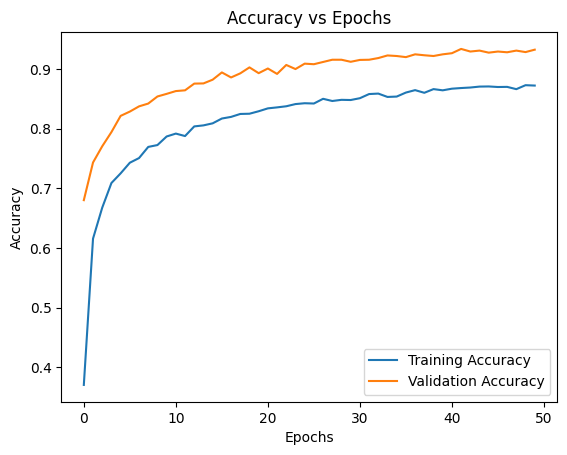

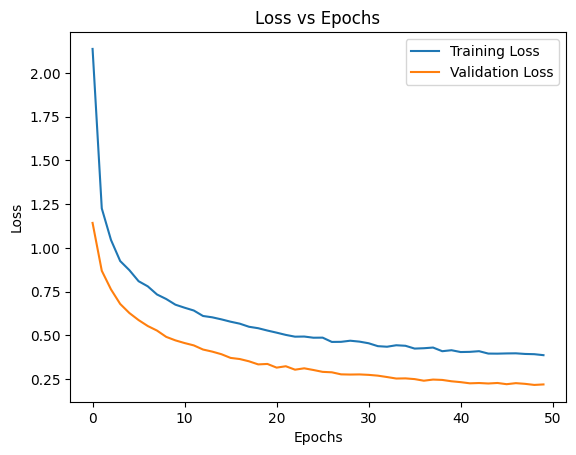

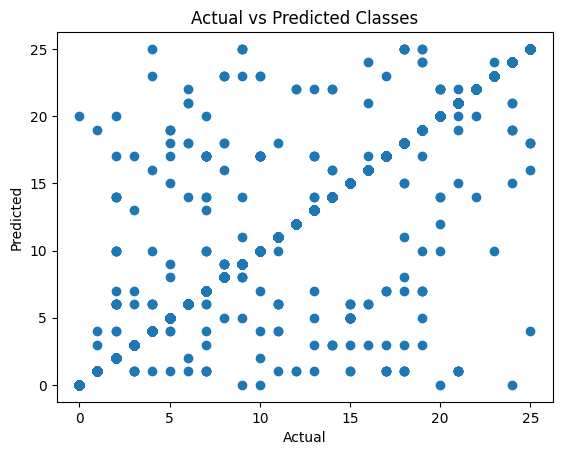

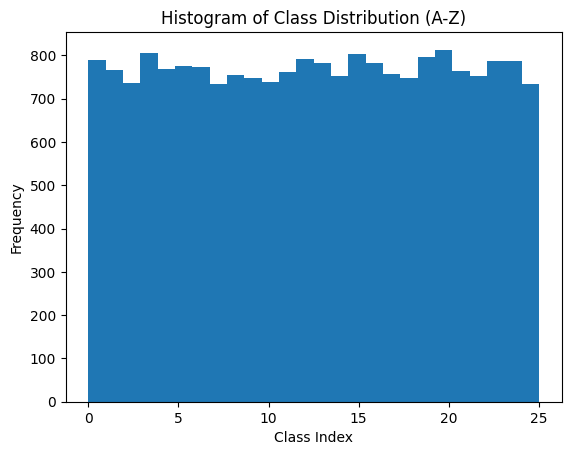

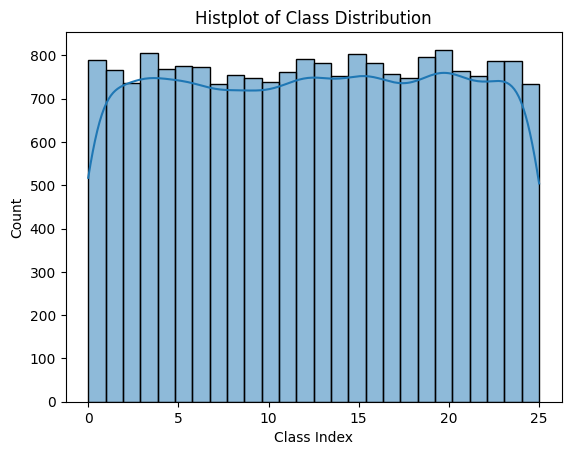

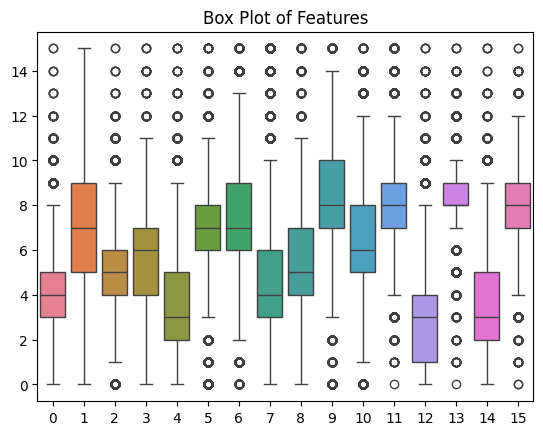

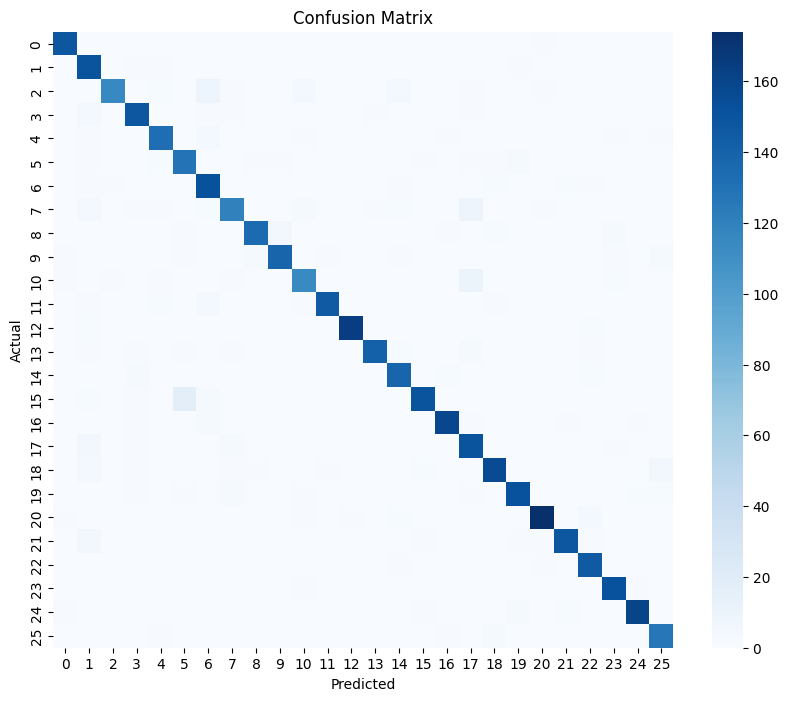

In [2]:


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load Dataset
data = pd.read_csv("letter-recognition.data", header=None)

# Features and Target
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Encode labels (A-Z → 0-25)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# BUILD DNN MODEL
# ===============================

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(16,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(26, activation='softmax')
])

# Compile Model
learning_rate = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ===============================
# MODEL EVALUATION
# ===============================

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("\n===== MODEL PERFORMANCE METRICS =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\n===== MODEL CONFIGURATION =====")
print("Number of Hidden Layers: 3")
print("Total Layers (including output):", len(model.layers))
print("Activation Function (Hidden Layers): ReLU")
print("Output Activation Function: Softmax")
print("Epochs Used: 50")
print("Batch Size: 32")
print("Learning Rate:", learning_rate)
print("Optimizer: Adam")

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted Classes")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()
plt.figure()
plt.hist(y, bins=26)
plt.title("Histogram of Class Distribution (A-Z)")
plt.xlabel("Class Index")
plt.ylabel("Frequency")
plt.show()


plt.figure()
sns.histplot(y, bins=26, kde=True)
plt.title("Histplot of Class Distribution")
plt.xlabel("Class Index")
plt.show()


plt.figure()
sns.boxplot(data=pd.DataFrame(X))
plt.title("Box Plot of Features")
plt.show()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()